# Round 3 — Options Analysis

Analysis of the 10 VEV vouchers and their underlying `VELVETFRUIT_EXTRACT`.

See `DESIGN.md` for the notebook outline.

## A. Setup & load

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import helpers

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:.6f}")

sns.set_theme(context="notebook", style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 4)

In [2]:
DATA_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", "Data"))
OUTPUT_DIR = os.path.abspath(os.path.join(os.getcwd(), "output"))
os.makedirs(OUTPUT_DIR, exist_ok=True)

PRICE_FILES = [
    "prices_round_3_day_0.csv",
    "prices_round_3_day_1.csv",
    "prices_round_3_day_2.csv",
]
TRADE_FILES = [
    "trades_round_3_day_0.csv",
    "trades_round_3_day_1.csv",
    "trades_round_3_day_2.csv",
]

STRIKES = [4000, 4500, 5000, 5100, 5200, 5300, 5400, 5500, 6000, 6500]
VOUCHERS = [f"VEV_{K}" for K in STRIKES]
UNDERLYING = "VELVETFRUIT_EXTRACT"

IV_DOWNSAMPLE = 10  # compute IV on every Nth row

In [3]:
prices_all = helpers.load_prices(DATA_DIR, PRICE_FILES)

# Underlying path + voucher rows
u = prices_all[prices_all["product"] == UNDERLYING].copy()
v = prices_all[prices_all["product"].isin(VOUCHERS)].copy()

# Attach strike integer + TTE years
v["strike"] = v["product"].str.replace("VEV_", "", regex=False).astype(int)
v["tte_years"] = [helpers.tte_years(int(d), int(t))
                  for d, t in zip(v["day"], v["timestamp"])]

# Attach underlying mid on (day, timestamp) — prices are tick-aligned
u_key = u[["day", "timestamp", "mid_price"]].rename(columns={"mid_price": "underlying_mid"})
v = v.merge(u_key, on=["day", "timestamp"], how="left")
v["moneyness"] = v["underlying_mid"] / v["strike"]

print(f"underlying rows: {len(u):>7,}")
print(f"voucher rows   : {len(v):>7,}")

underlying rows:  30,000
voucher rows   : 300,000


### A.5 Data quality summary

In [4]:
qc = (v.groupby(["strike", "day"])
        .agg(rows=("timestamp", "size"),
             nan_mid=("mid_price", lambda s: s.isna().sum()),
             zero_mid=("mid_price", lambda s: (s == 0).sum()),
             mean_quoted_size=("bid_volume_1", lambda s: s.fillna(0).mean()))
        .reset_index())
display(qc)

,strike,day,rows,nan_mid,zero_mid,mean_quoted_size
0,4000,0,10000,0,0,10.907000
1,4000,1,10000,0,0,10.948200
2,4000,2,10000,0,0,10.909400
3,4500,0,10000,0,0,8.920400
4,4500,1,10000,0,0,8.920900
5,4500,2,10000,0,0,9.011800
6,5000,0,10000,0,0,15.233600
7,5000,1,10000,0,0,15.316900
8,5000,2,10000,0,0,15.427800
9,5100,0,10000,0,0,19.096800


## B. Price behaviour

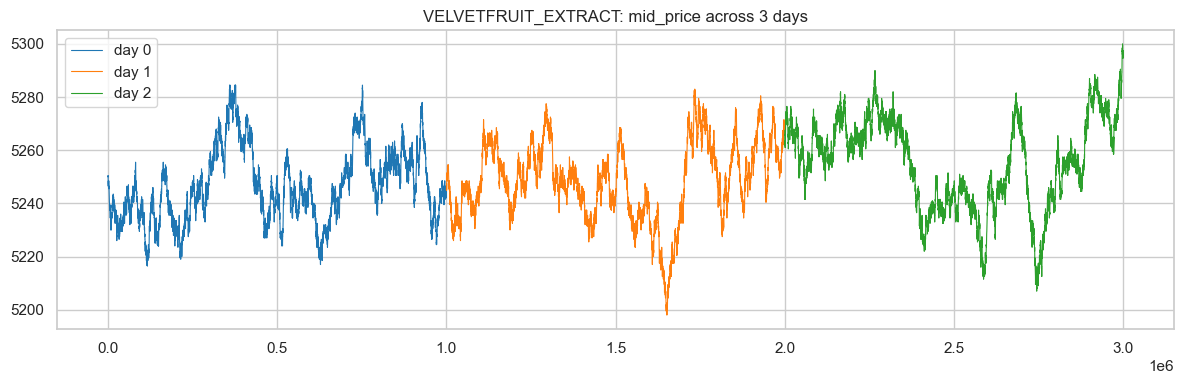

In [5]:
fig, ax = plt.subplots(figsize=(12, 4))
for d, color in zip(sorted(u["day"].unique()), sns.color_palette("tab10")):
    s = u[u["day"] == d].sort_values("timestamp")
    ax.plot(s["timestamp"].to_numpy() + d * helpers.TIMESTAMPS_PER_DAY,
            s["mid_price"].to_numpy(), label=f"day {d}", color=color, lw=0.8)
ax.set_title(f"{UNDERLYING}: mid_price across 3 days")
ax.legend()
plt.tight_layout()
plt.show()

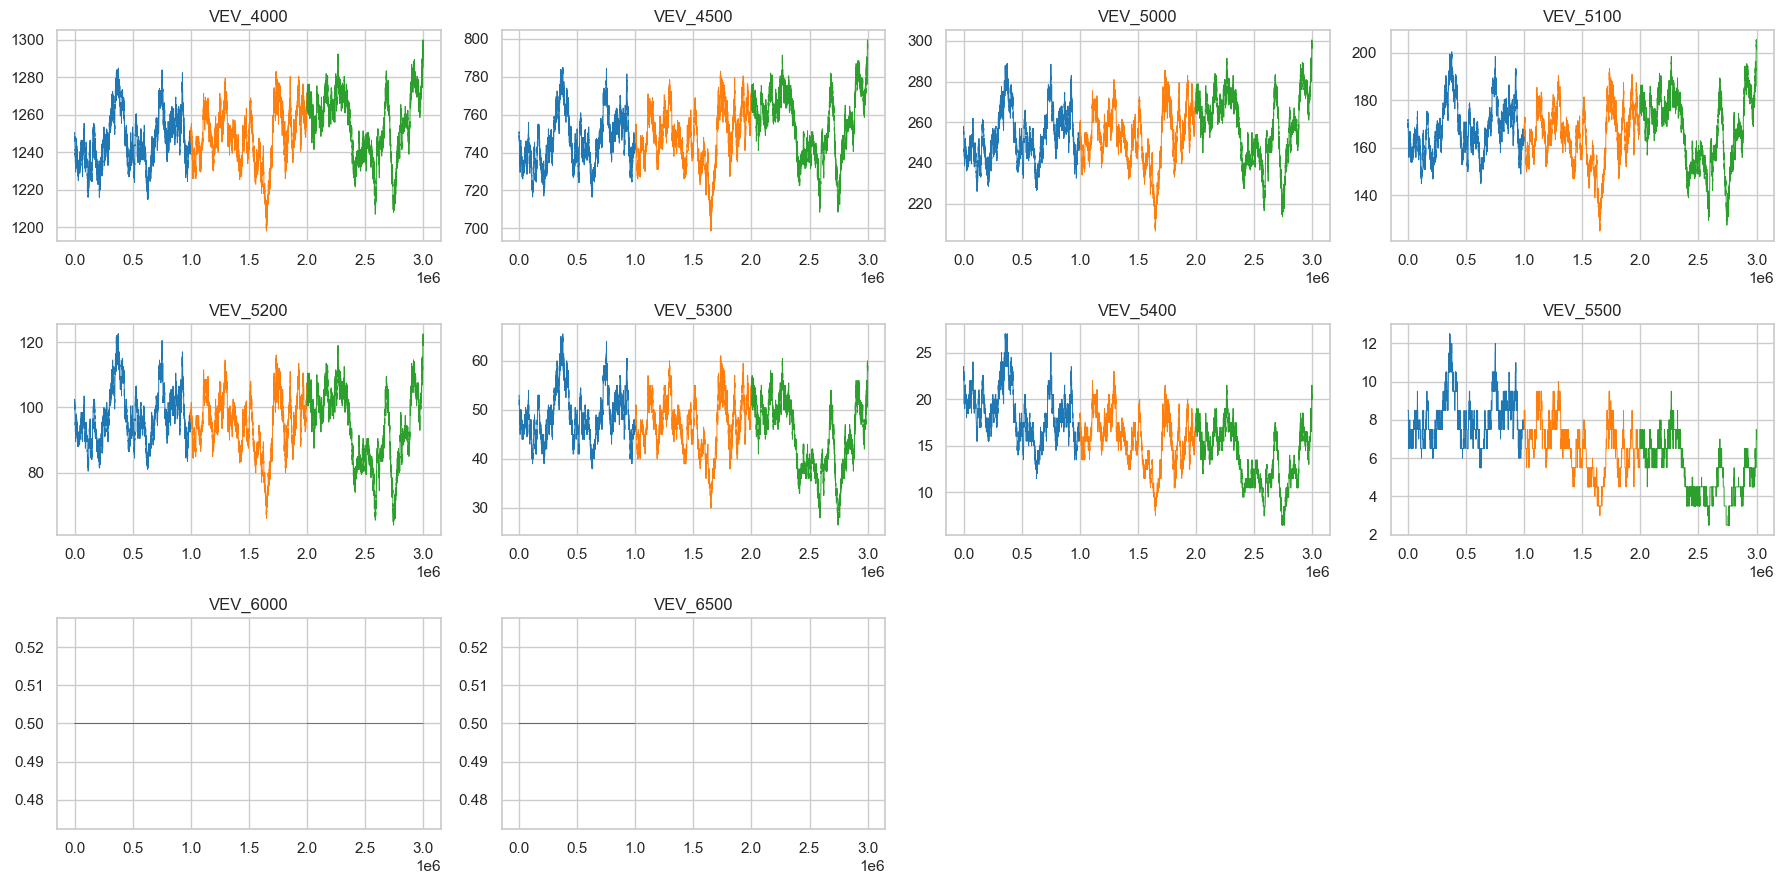

In [6]:
fig, axes = plt.subplots(3, 4, figsize=(18, 9), sharex=False)
for ax, K in zip(axes.ravel(), STRIKES):
    s_v = v[v["strike"] == K].sort_values(["day", "timestamp"])
    for d, color in zip(sorted(s_v["day"].unique()), sns.color_palette("tab10")):
        sd = s_v[s_v["day"] == d]
        ax.plot(sd["timestamp"].to_numpy() + d * helpers.TIMESTAMPS_PER_DAY,
                sd["mid_price"].to_numpy(), color=color, lw=0.7, label=f"d{d}")
    ax.set_title(f"VEV_{K}")
# turn off unused axes
for ax in axes.ravel()[len(STRIKES):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

In [7]:
per_strike = (v.groupby("strike")
                .agg(rows=("timestamp", "size"),
                     mean_mid=("mid_price", "mean"),
                     mean_spread=("mid_price", lambda s: (s.std() if len(s) else np.nan)),
                     mean_quoted_size_bid=("bid_volume_1", lambda s: s.fillna(0).mean()),
                     mean_quoted_size_ask=("ask_volume_1", lambda s: s.fillna(0).mean()))
                .reset_index())
# Recompute mean_spread more precisely as ask_price_1 - bid_price_1
spread = (v.assign(spread=v["ask_price_1"] - v["bid_price_1"])
            .groupby("strike")["spread"].mean().rename("mean_spread"))
per_strike = per_strike.drop(columns="mean_spread").merge(spread, on="strike")
display(per_strike)

,strike,rows,mean_mid,mean_quoted_size_bid,mean_quoted_size_ask,mean_spread
0,4000,30000,1250.109800,10.921533,10.919900,20.813467
1,4500,30000,750.109567,8.951033,8.948767,15.852667
2,5000,30000,255.022400,15.326100,15.484267,6.043333
3,5100,30000,166.805450,19.248367,19.347933,4.295833
4,5200,30000,95.548767,22.563433,22.508733,2.888133
5,5300,30000,46.759933,20.283800,20.242867,2.106800
6,5400,30000,15.951917,21.763033,21.719133,1.381433
7,5500,30000,6.641350,22.178067,22.171667,1.149767
8,6000,30000,0.500000,22.476167,22.478867,1.000000
9,6500,30000,0.500000,15.479433,15.482133,1.000000


## C. Voucher ↔ underlying relationship

If a voucher is a real option, its mid should move with the underlying.
The scatter slope per strike is an empirical delta.

Moneyness = underlying / strike. Moneyness < 1 = out-of-money, > 1 = in-the-money.

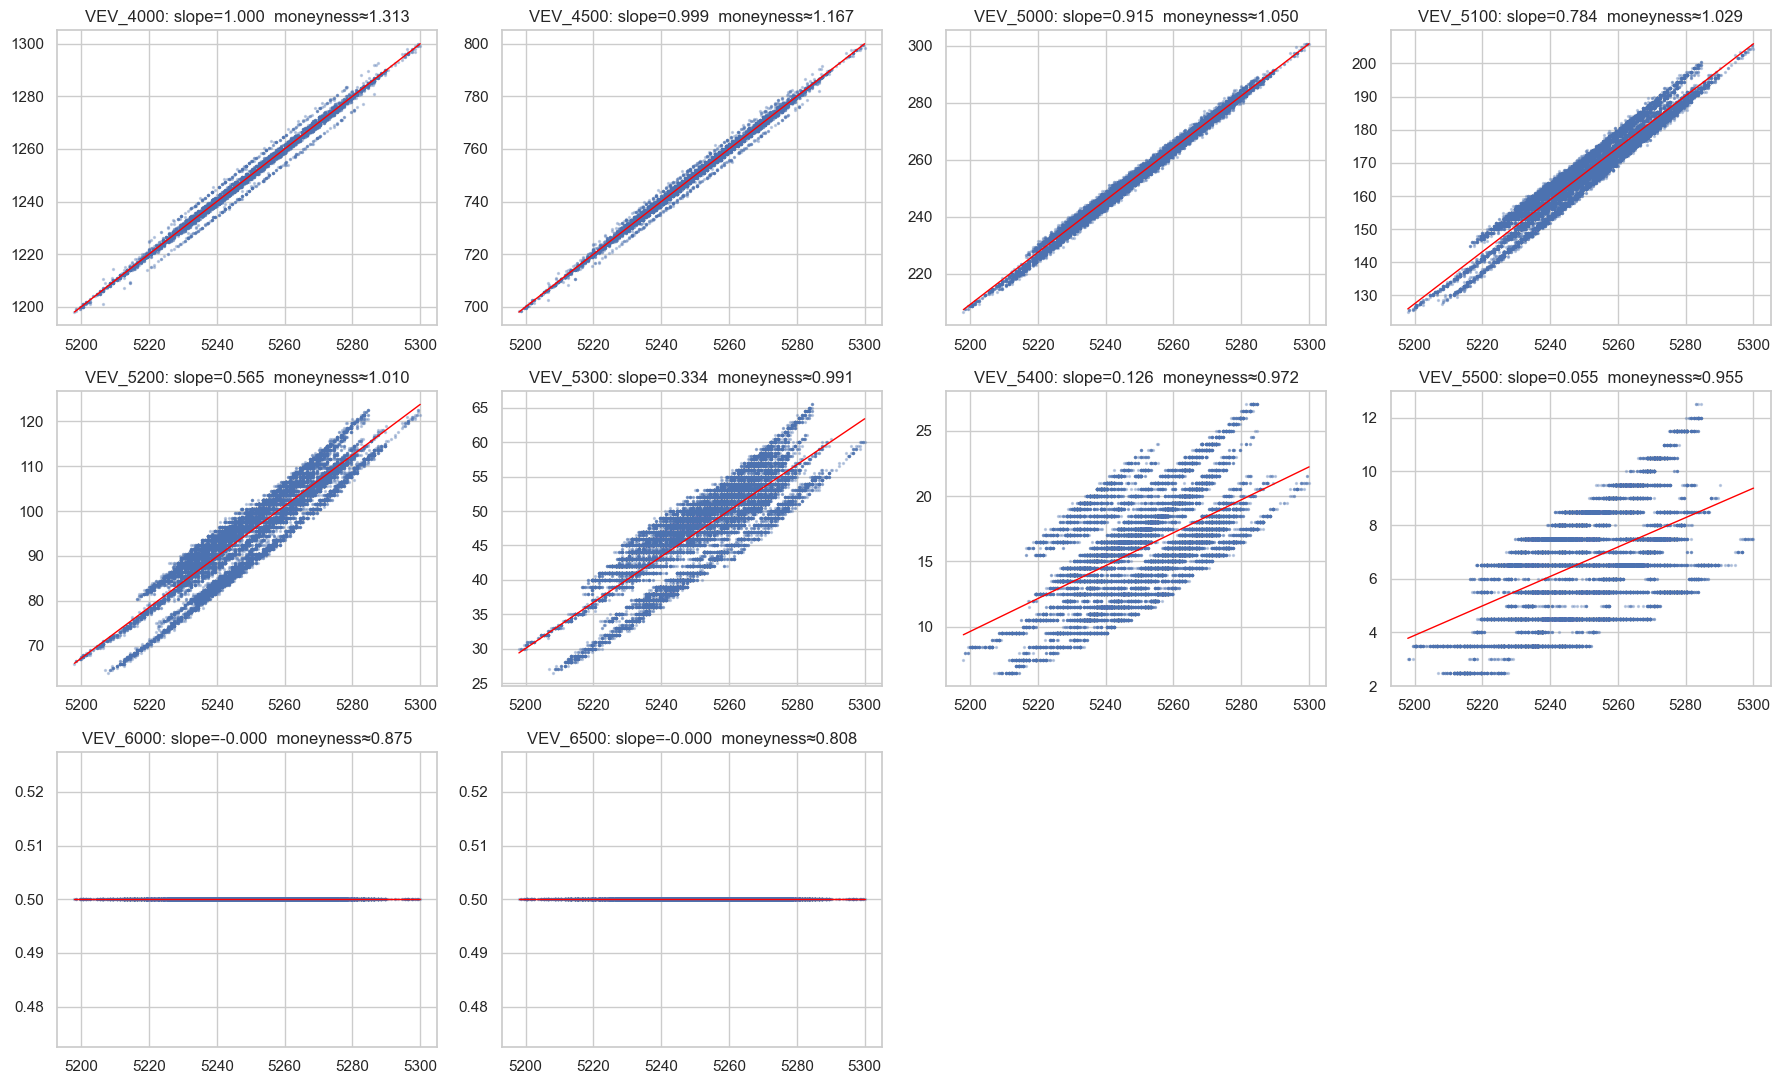

Empirical deltas: {4000: np.float64(0.9997), 4500: np.float64(0.9994), 5000: np.float64(0.9153), 5100: np.float64(0.7843), 5200: np.float64(0.5651), 5300: np.float64(0.3336), 5400: np.float64(0.1257), 5500: np.float64(0.0549), 6000: np.float64(-0.0), 6500: np.float64(-0.0)}


In [8]:
fig, axes = plt.subplots(3, 4, figsize=(18, 11))
slopes = {}
for ax, K in zip(axes.ravel(), STRIKES):
    s = v[v["strike"] == K].dropna(subset=["mid_price", "underlying_mid"])
    if len(s) < 100:
        ax.axis("off"); continue
    ax.scatter(s["underlying_mid"], s["mid_price"], s=2, alpha=0.3)
    slope, intercept = np.polyfit(s["underlying_mid"].to_numpy(float),
                                  s["mid_price"].to_numpy(float), 1)
    slopes[K] = slope
    xs = np.linspace(s["underlying_mid"].min(), s["underlying_mid"].max(), 50)
    ax.plot(xs, slope * xs + intercept, color="red", lw=1.0)
    mean_money = s["moneyness"].mean()
    ax.set_title(f"VEV_{K}: slope={slope:.3f}  moneyness≈{mean_money:.3f}")
for ax in axes.ravel()[len(STRIKES):]:
    ax.axis("off")
plt.tight_layout()
plt.show()
print("Empirical deltas:", {k: round(s, 4) for k, s in slopes.items()})

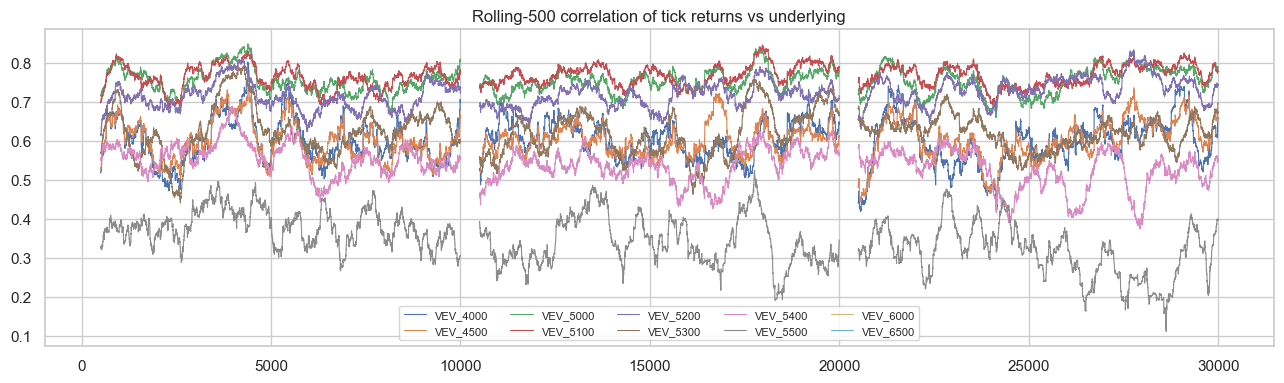

In [9]:
ROLL = 500
fig, ax = plt.subplots(figsize=(13, 4))
for K in STRIKES:
    s = v[v["strike"] == K].sort_values(["day", "timestamp"]).copy()
    s["voucher_ret"] = s.groupby("day")["mid_price"].diff()
    s["underlying_ret"] = s.groupby("day")["underlying_mid"].diff()
    rc = (s[["voucher_ret", "underlying_ret"]]
            .rolling(ROLL).corr().unstack()["voucher_ret"]["underlying_ret"])
    ax.plot(rc.to_numpy(), label=f"VEV_{K}", lw=0.8)
ax.set_title(f"Rolling-{ROLL} correlation of tick returns vs underlying")
ax.legend(ncol=5, fontsize=8, loc="lower center")
plt.tight_layout()
plt.show()

In [10]:
viols = v.assign(intrinsic=np.maximum(v["underlying_mid"] - v["strike"], 0))
viols = viols[viols["mid_price"] < viols["intrinsic"] - 1e-6]
print(f"intrinsic-floor violations: {len(viols)} rows "
      f"({100*len(viols)/max(len(v), 1):.3f}%)")
if len(viols):
    display(viols.groupby("strike").size().rename("violations"))

intrinsic-floor violations: 11801 rows (3.934%)


strike
4000    2986
4500    8812
5000       3
Name: violations, dtype: int64

## D. Implied volatility core

Implied volatility (IV) is the sigma that makes the BS price match the
observed voucher mid. Plotted vs strike at a snapshot, the U-shape is the
**smile** — far-from-money options are richer on a vol basis than at-the-money.

In [11]:
# Downsample for IV solves. Keep a copy of raw 'v' for plots that don't need IV.
iv_rows = v.iloc[::IV_DOWNSAMPLE].copy().reset_index(drop=True)
print(f"IV solve rows: {len(iv_rows):,}")

def _iv(row):
    return helpers.implied_vol_call(
        price=float(row["mid_price"]),
        S=float(row["underlying_mid"]),
        K=float(row["strike"]),
        T=float(row["tte_years"]),
    )

iv_rows["iv"] = iv_rows.apply(_iv, axis=1)
finite = iv_rows["iv"].notna().mean()
print(f"finite IV fraction: {finite:.3f}")

IV solve rows: 30,000


finite IV fraction: 0.917


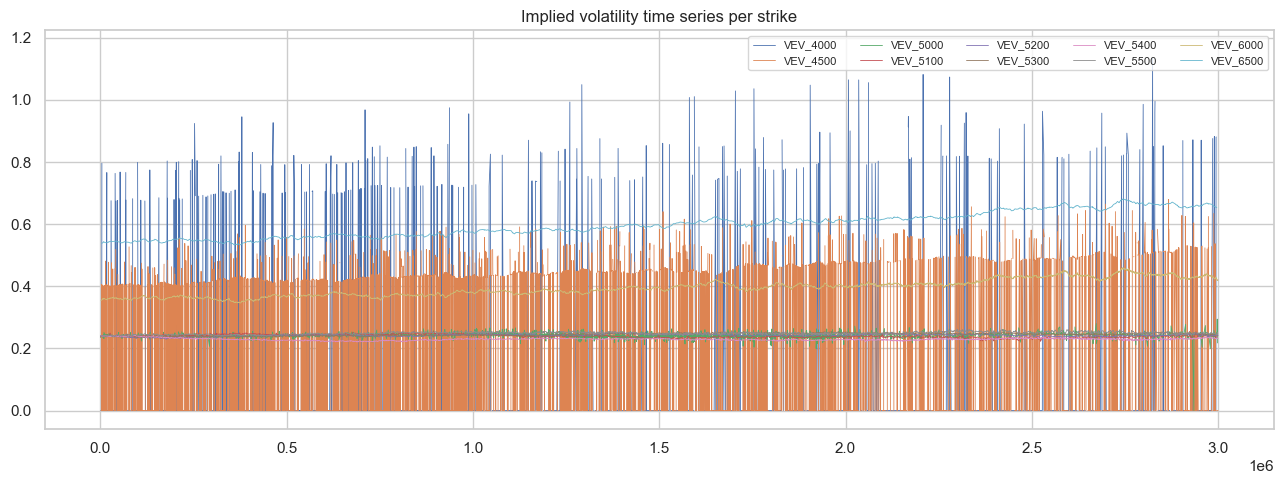

In [12]:
fig, ax = plt.subplots(figsize=(13, 5))
for K in STRIKES:
    s = iv_rows[iv_rows["strike"] == K].sort_values(["day", "timestamp"])
    if s["iv"].notna().sum() == 0:
        continue
    x = s["timestamp"].to_numpy() + s["day"].to_numpy() * helpers.TIMESTAMPS_PER_DAY
    ax.plot(x, s["iv"].to_numpy(), label=f"VEV_{K}", lw=0.6)
ax.set_title("Implied volatility time series per strike")
ax.legend(ncol=5, fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()

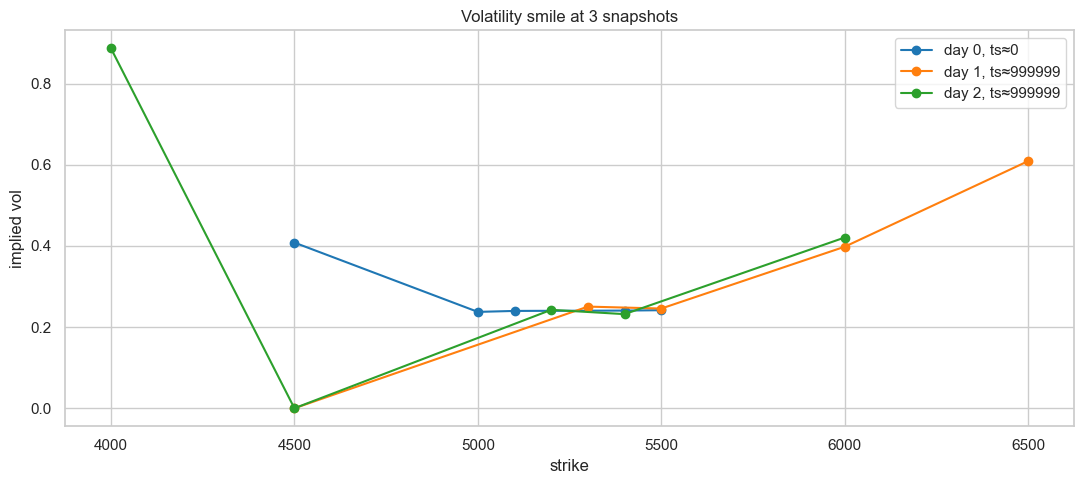

In [13]:
SNAPSHOTS = [
    (0, 0),
    (1, helpers.TIMESTAMPS_PER_DAY - 1),
    (2, helpers.TIMESTAMPS_PER_DAY - 1),
]

def nearest_snapshot(day, ts, window=1000):
    mask = (iv_rows["day"] == day) & (iv_rows["timestamp"].between(ts - window, ts + window))
    return iv_rows[mask]

fig, ax = plt.subplots(figsize=(11, 5))
for (d, ts), color in zip(SNAPSHOTS, sns.color_palette("tab10")):
    snap = nearest_snapshot(d, ts).dropna(subset=["iv"])
    if snap.empty:
        continue
    smile = snap.groupby("strike")["iv"].mean().reset_index()
    ax.plot(smile["strike"], smile["iv"], marker="o",
            label=f"day {d}, ts≈{ts}", color=color)
ax.set_xlabel("strike")
ax.set_ylabel("implied vol")
ax.set_title("Volatility smile at 3 snapshots")
ax.legend()
plt.tight_layout()
plt.show()

,strike,mean,std,min,max,count
0,4000,0.091735,0.257298,0.000100,1.165714,2206
1,4500,0.194823,0.228929,0.000100,0.679605,5330
2,5000,0.241405,0.007845,0.000100,0.294426,3688
3,5100,0.240257,0.005213,0.222738,0.254947,1048
4,5200,0.241981,0.003493,0.228897,0.251733,1090
5,5300,0.245262,0.004353,0.234923,0.253627,1112
6,5400,0.229755,0.003464,0.220452,0.241752,2495
7,5500,0.249379,0.003991,0.237759,0.261497,2839
8,6000,0.402671,0.026940,0.346304,0.460042,6688
9,6500,0.602500,0.040533,0.533267,0.680689,1024


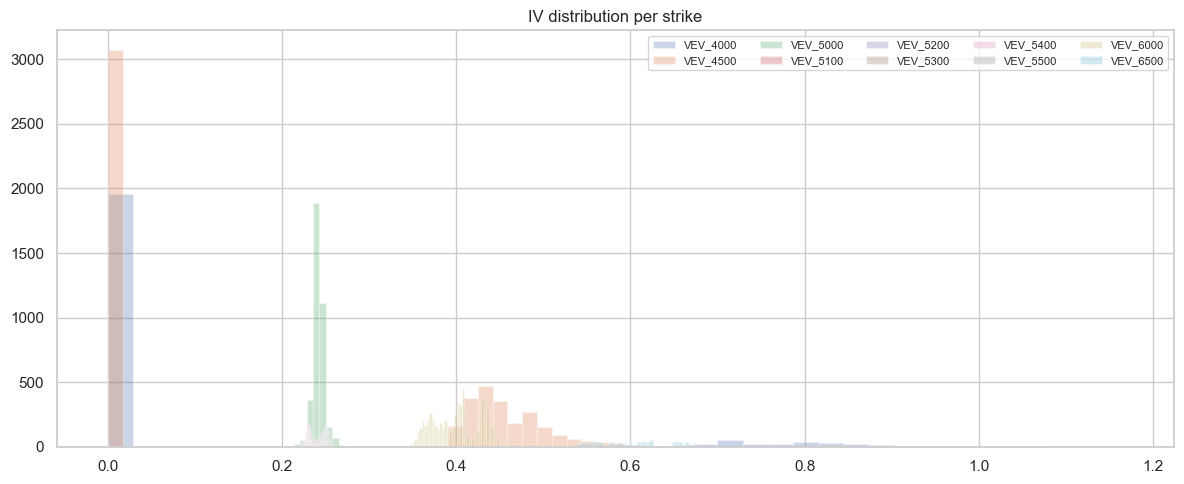

In [14]:
fig, ax = plt.subplots(figsize=(12, 5))
stats = (iv_rows.dropna(subset=["iv"])
                .groupby("strike")["iv"]
                .agg(["mean", "std", "min", "max", "count"])
                .reset_index())
display(stats)
for K in STRIKES:
    s = iv_rows[(iv_rows["strike"] == K) & iv_rows["iv"].notna()]
    if len(s) < 10:
        continue
    ax.hist(s["iv"], bins=40, alpha=0.3, label=f"VEV_{K}")
ax.set_title("IV distribution per strike")
ax.legend(ncol=5, fontsize=8)
plt.tight_layout()
plt.show()

In [15]:
# Rich/cheap: iv - median_iv_across_strikes at the same (day, timestamp)
piv = (iv_rows.dropna(subset=["iv"])
              .pivot_table(index=["day", "timestamp"], columns="strike", values="iv"))
median_iv = piv.median(axis=1)
rich_cheap = piv.subtract(median_iv, axis=0)
rc_summary = rich_cheap.mean().rename("mean_iv_vs_median").to_frame()
rc_summary["abs"] = rc_summary["mean_iv_vs_median"].abs()
rc_summary = rc_summary.sort_values("abs", ascending=False).drop(columns="abs")
display(rc_summary)

,mean_iv_vs_median
strike,
4000,0.000000
4500,0.000000
5000,0.000000
5100,0.000000
5200,0.000000
5300,0.000000
5400,0.000000
5500,0.000000
6000,0.000000


## E. Exports

In [16]:
iv_export = iv_rows[["day", "timestamp", "strike", "mid_price",
                      "underlying_mid", "moneyness", "tte_years", "iv"]].copy()
iv_export = iv_export.rename(columns={"mid_price": "voucher_mid"})
iv_export.to_csv(os.path.join(OUTPUT_DIR, "iv_timeseries.csv"), index=False)
print("iv_timeseries.csv  rows:", len(iv_export))

iv_timeseries.csv  rows: 30000


In [17]:
summary_rows = []
for K in STRIKES:
    s = iv_rows[iv_rows["strike"] == K]
    s_raw = v[v["strike"] == K]
    summary_rows.append({
        "strike": K,
        "n_rows": len(s_raw),
        "mean_spread": (s_raw["ask_price_1"] - s_raw["bid_price_1"]).mean(),
        "mean_quoted_size_bid": s_raw["bid_volume_1"].fillna(0).mean(),
        "mean_quoted_size_ask": s_raw["ask_volume_1"].fillna(0).mean(),
        "mean_iv": s["iv"].mean(),
        "iv_std": s["iv"].std(),
        "empirical_delta": slopes.get(K, float("nan")),
        "mean_moneyness": s_raw["moneyness"].mean(),
    })
voucher_summary = pd.DataFrame(summary_rows)
voucher_summary.to_csv(os.path.join(OUTPUT_DIR, "voucher_price_summary.csv"), index=False)
display(voucher_summary)

,strike,n_rows,mean_spread,mean_quoted_size_bid,mean_quoted_size_ask,mean_iv,iv_std,empirical_delta,mean_moneyness
0,4000,30000,20.813467,10.921533,10.919900,0.091735,0.257298,0.999672,1.312525
1,4500,30000,15.852667,8.951033,8.948767,0.194823,0.228929,0.999430,1.166688
2,5000,30000,6.043333,15.326100,15.484267,0.241405,0.007845,0.915320,1.050020
3,5100,30000,4.295833,19.248367,19.347933,0.240257,0.005213,0.784321,1.029431
4,5200,30000,2.888133,22.563433,22.508733,0.241981,0.003493,0.565115,1.009634
5,5300,30000,2.106800,20.283800,20.242867,0.245262,0.004353,0.333603,0.990585
6,5400,30000,1.381433,21.763033,21.719133,0.229755,0.003464,0.125748,0.972240
7,5500,30000,1.149767,22.178067,22.171667,0.249379,0.003991,0.054875,0.954563
8,6000,30000,1.000000,22.476167,22.478867,0.402671,0.026940,-0.000000,0.875016
9,6500,30000,1.000000,15.479433,15.482133,0.602500,0.040533,-0.000000,0.807707


In [18]:
# Per-strike OLS slope, R^2, rolling correlation stats vs underlying
rows = []
ROLL = 500
for K in STRIKES:
    s = v[v["strike"] == K].sort_values(["day", "timestamp"]).copy()
    if len(s) < 50:
        continue
    s["voucher_ret"] = s.groupby("day")["mid_price"].diff()
    s["underlying_ret"] = s.groupby("day")["underlying_mid"].diff()
    rc = (s[["voucher_ret", "underlying_ret"]]
            .rolling(ROLL).corr().unstack()["voucher_ret"]["underlying_ret"])
    ols_slope, ols_intercept = np.polyfit(
        s["underlying_mid"].dropna().to_numpy(float),
        s["mid_price"].dropna().to_numpy(float), 1,
    ) if s[["underlying_mid", "mid_price"]].dropna().shape[0] > 1 else (float("nan"), float("nan"))
    preds = ols_slope * s["underlying_mid"] + ols_intercept
    ss_res = float(((s["mid_price"] - preds) ** 2).sum())
    ss_tot = float(((s["mid_price"] - s["mid_price"].mean()) ** 2).sum())
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else float("nan")
    rows.append({
        "strike": K,
        "ols_slope": ols_slope,
        "r_squared": r2,
        "rolling_corr_mean": rc.mean(),
        "rolling_corr_std": rc.std(),
    })
corr_summary = pd.DataFrame(rows)
corr_summary.to_csv(os.path.join(OUTPUT_DIR, "voucher_underlying_corr.csv"), index=False)
display(corr_summary)

,strike,ols_slope,r_squared,rolling_corr_mean,rolling_corr_std
0,4000,0.999672,0.997195,0.600482,0.056136
1,4500,0.999430,0.997646,0.600808,0.048523
2,5000,0.915320,0.990456,0.753614,0.031801
3,5100,0.784321,0.925574,0.765953,0.028546
4,5200,0.565115,0.835374,0.720038,0.035002
5,5300,0.333603,0.700943,0.621304,0.056132
6,5400,0.125748,0.328521,0.538501,0.047824
7,5500,0.054875,0.243312,0.344284,0.065484
8,6000,-0.000000,NaN,NaN,NaN
9,6500,-0.000000,NaN,NaN,NaN


### Findings

_Fill in after running. The notebook is set up to answer:_

- Which strikes are most/least liquid (see `voucher_price_summary.csv`).
- Smile regime: classic smile, skew, or flat (see Part D smile plot).
- Which strikes are persistently rich or cheap relative to the cross-strike
  median IV (see Part D.6 table).
- Empirical delta vs strike monotonicity check (Part C.2 scatters; deep-ITM
  should approach 1).
- Any intrinsic-floor violations (Part C.4).